# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Data import

In [2]:
longtitude = []
latitude = []
height = []
with open("channel_data.txt", "r") as f:
    for line in f:
        data = line.split()
        latitude.append(float(data[0]))
        longtitude.append(float(data[1]))
        height.append(int(data[2]))
longtitude = np.array(longtitude)
latitude = np.array(latitude)
height = np.array(height)

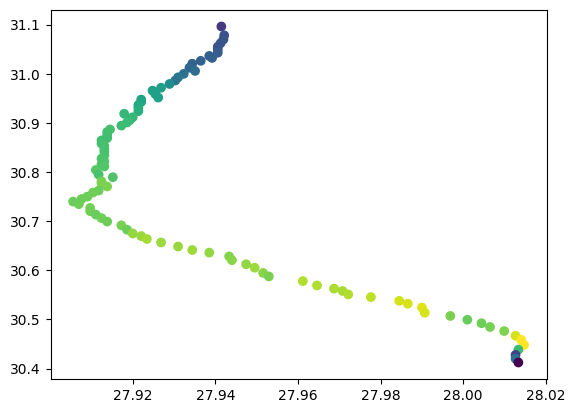

In [3]:
plt.scatter(longtitude, latitude, c=height, cmap="viridis")

# Problem 2

In [4]:
# Function to calculate the distance between two points on the Earth using the Haversine formula
def haversine_np(lat1, lon1, lat2, lon2, radius=6371000):
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return radius * c

In [5]:
distanceFromZero = [0]
for i in range(1, len(longtitude)):
    # append distance in meter from (0,0) to (longtitude[i], latitude[i])
    distanceFromZero.append(haversine_np(latitude[0], longtitude[0], latitude[i], longtitude[i]))
distanceFromZero = np.array(distanceFromZero)

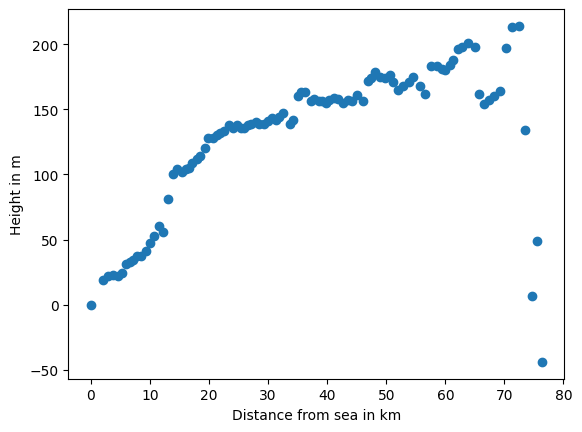

In [6]:
plt.figure()
plt.scatter(distanceFromZero/1000, height)
plt.xlabel("Distance from sea in km")
plt.ylabel("Height in m")
plt.show()

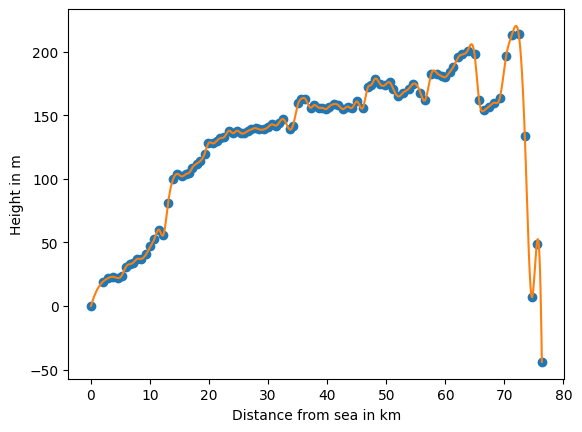

In [7]:
# interpolate the height
interpolator = interp1d(distanceFromZero, height, kind="cubic")
x = np.linspace(0, distanceFromZero[-1], 1000)
y = interpolator(x)
plt.figure()
plt.plot(distanceFromZero/1000, height, "o", label="Data points")
plt.plot(x/1000, y)
plt.xlabel("Distance from sea in km")
plt.ylabel("Height in m")
plt.show()

In [8]:
dist = 250
with open("heights.txt", "w") as f:
    for i in range(0, int(np.floor(distanceFromZero[-1])), dist):
        print(interpolator(i).flatten()[0], file=f)

# Problem 3

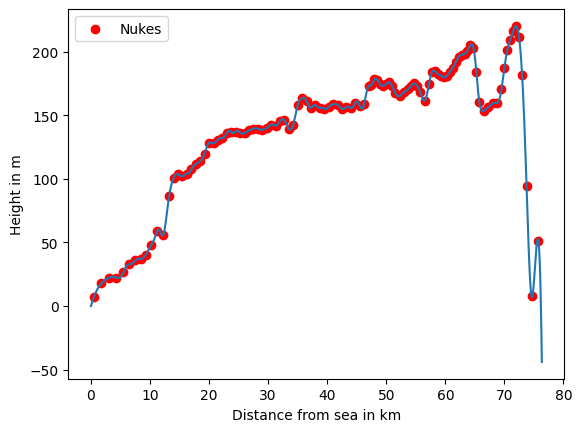

In [10]:
objVal = 108
nukes = [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0]
nukesX = []
nukesY = []
for i in range(len(nukes)):
    if nukes[i] == 1.0:
        nukesX.append(i * dist)
        nukesY.append(interpolator(i * dist).flatten()[0])
nukesX = np.array(nukesX)
nukesY = np.array(nukesY)
        
plt.figure()
plt.plot(x/1000, y)
plt.scatter(nukesX/1000, nukesY, color="red", label="Nukes")
plt.xlabel("Distance from sea in km")
plt.ylabel("Height in m")
plt.legend()
plt.show()

In [11]:
neightbor = False 

for i in range(1, len(nukes)):
    if nukes[i] == 1.0 and nukes[i-1] == 1.0:
        neightbor = True
        break 

print("Is there any neighbor nukes?", neightbor)


Is there any neighbor nukes? False


# Problem 4

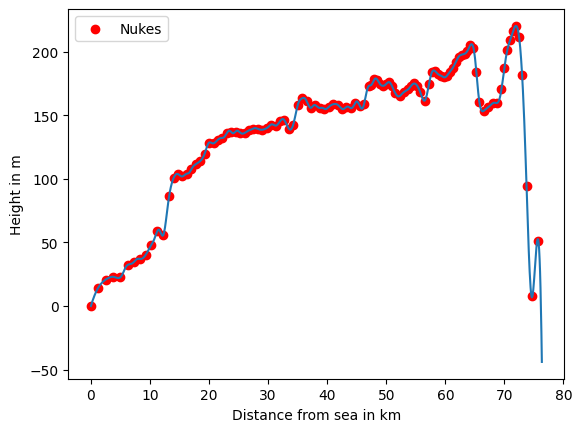

Is there any neighbor nukes? False


In [12]:
objVal = 27934
nukes = [1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0]
nukesX = []
nukesY = []
for i in range(len(nukes)):
    if nukes[i] == 1.0:
        nukesX.append(i * dist)
        nukesY.append(interpolator(i * dist).flatten()[0])
nukesX = np.array(nukesX)
nukesY = np.array(nukesY)
        
plt.figure()
plt.plot(x/1000, y)
plt.scatter(nukesX/1000, nukesY, color="red", label="Nukes")
plt.xlabel("Distance from sea in km")
plt.ylabel("Height in m")
plt.legend()
plt.show()

neightbor = False 

for i in range(1, len(nukes)):
    if nukes[i] == 1.0 and nukes[i-1] == 1.0:
        neightbor = True
        break 

print("Is there any neighbor nukes?", neightbor)


# Problem 5

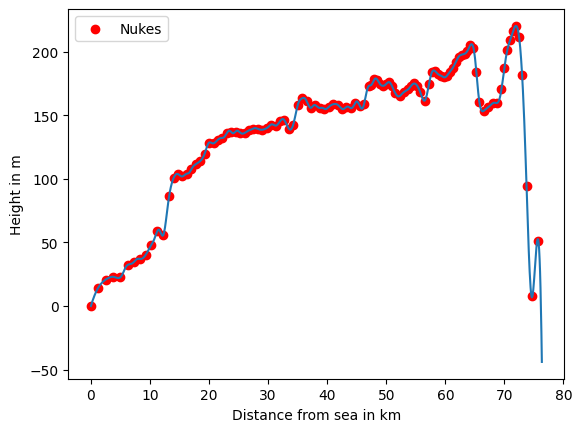

In [10]:
objVal = 27934
nukes = [1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0]
nukesX = []
nukesY = []
for i in range(len(nukes)):
    if nukes[i] == 1.0:
        nukesX.append(i * dist)
        nukesY.append(interpolator(i * dist).flatten()[0])
nukesX = np.array(nukesX)
nukesY = np.array(nukesY)
        
plt.figure()
plt.plot(x/1000, y)
plt.scatter(nukesX/1000, nukesY, color="red", label="Nukes")
plt.xlabel("Distance from sea in km")
plt.ylabel("Height in m")
plt.legend()
plt.show()

# Problem 6

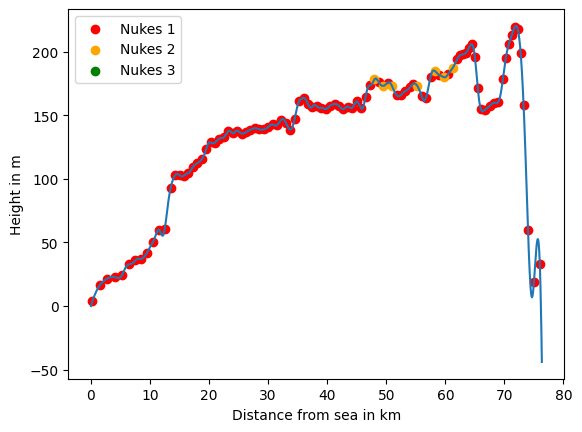

In [14]:
objVal = 26254
nukes = [0 for _ in range(int(np.floor(distanceFromZero[-1])) // dist)]

with open("SettingsResults.txt", "r") as f:
    for line in f:
        data = line.split()
        idx = int(data[0])
        val = int(data[1])
        nukes[idx] = val

nukesX = [[] for _ in range(3)]
nukesY = [[] for _ in range(3)]
for i in range(len(nukes)):
    if nukes[i] != 0:
        nukesX[nukes[i]-1].append(i * dist)
        nukesY[nukes[i]-1].append(interpolator(i * dist).flatten()[0])

colors = ["red", "orange", "green"]
plt.figure()
plt.plot(x/1000, y)
for i in range(3):
    nx = np.array(nukesX[i])
    ny = np.array(nukesY[i])
    plt.scatter(nx/1000, ny, color=colors[i], label=f"Nukes {i+1}")
plt.xlabel("Distance from sea in km")
plt.ylabel("Height in m")
plt.legend()
plt.show()